In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

对比不同解码方式的rollout

In [ ]:
import re
import numpy as np
from pathlib import Path
from collections import Counter

def parse_diversity_line(line):
    """
    解析单行diversity数据，提取完整信息
    示例: diversity| distinct_answer_num: 6 | all_answer_num: 8 | distinct_answer_ratio: 0.75 | best_answer_ratio: 0.38 | correct_answer_number: 1 | best_is_correct: 0 | extracted_answers: ['0', '33.33', '22', '33.33', '33.33', '36.25', '24', '42'] | majority_answer: 33.33 | ground_truth_answer: 22
    """
    # 解析基础指标
    pattern = r'diversity\|\s*distinct_answer_num:\s*(\d+).*?all_answer_num:\s*(\d+).*?best_answer_ratio:\s*([0-9.]+).*?correct_answer_number:\s*(\d+).*?best_is_correct:\s*(\d+)'
    match = re.search(pattern, line)
    
    if not match:
        return None
    
    # 提取答案列表
    answers_pattern = r'extracted_answers:\s*\[(.*?)\]'
    answers_match = re.search(answers_pattern, line)
    extracted_answers = []
    if answers_match:
        # 解析答案列表字符串
        answers_str = answers_match.group(1)
        # 处理引号内的内容
        extracted_answers = re.findall(r"'([^']*)'", answers_str)
    
    # 提取多数投票答案
    majority_pattern = r'majority_answer:\s*([^\s|]+)'
    majority_match = re.search(majority_pattern, line)
    majority_answer = majority_match.group(1) if majority_match else None
    
    # 提取真实答案
    truth_pattern = r'ground_truth_answer:\s*([^\s|]+)'
    truth_match = re.search(truth_pattern, line)
    ground_truth = truth_match.group(1) if truth_match else None
    
    return {
        'distinct_answer_num': int(match.group(1)),
        'all_answer_num': int(match.group(2)),
        'best_answer_ratio': float(match.group(3)),
        'correct_answer_number': int(match.group(4)),
        'best_is_correct': int(match.group(5)),
        'extracted_answers': extracted_answers,
        'majority_answer': majority_answer,
        'ground_truth': ground_truth
    }

def calculate_reward_metrics(answers, majority_answer, ground_truth):
    """
    计算reward accuracy和相关指标
    
    Args:
        answers: 所有rollout的答案列表
        majority_answer: 多数投票答案
        ground_truth: 真实答案
    
    Returns:
        dict: 包含各项指标
    """
    n = len(answers)
    if n == 0 or majority_answer is None or ground_truth is None:
        return {
            'reward_accuracy': 0,
            'true_positive_ratio': 0,
            'true_negative_ratio': 0,
            'false_positive_ratio': 0,
            'false_negative_ratio': 0
        }
    
    # 为每个rollout计算估计奖励和真实奖励
    tp = fp = tn = fn = 0
    
    for ans in answers:
        est_reward = 1 if ans == majority_answer else 0  # 估计奖励：是否匹配多数投票
        true_reward = 1 if ans == ground_truth else 0     # 真实奖励：是否真实正确
        
        if est_reward == 1 and true_reward == 1:
            tp += 1  # True Positive: 估计正确且真实正确
        elif est_reward == 1 and true_reward == 0:
            fp += 1  # False Positive: 估计正确但真实错误
        elif est_reward == 0 and true_reward == 1:
            fn += 1  # False Negative: 估计错误但真实正确
        elif est_reward == 0 and true_reward == 0:
            tn += 1  # True Negative: 估计错误且真实错误
    
    # 计算各项指标
    total = tp + fp + tn + fn
    
    # Reward Accuracy: 估计奖励与真实奖励一致的比例
    reward_accuracy = (tp + tn) / total if total > 0 else 0
    
    # True Positive Ratio: TP / (TP + FN)
    true_positive_ratio = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # True Negative Ratio: TN / (TN + FP)
    true_negative_ratio = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # False Positive Ratio: FP / (FP + TN)
    false_positive_ratio = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # False Negative Ratio: FN / (FN + TP)
    false_negative_ratio = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    return {
        'reward_accuracy': reward_accuracy,
        'true_positive_ratio': true_positive_ratio,
        'true_negative_ratio': true_negative_ratio,
        'false_positive_ratio': false_positive_ratio,
        'false_negative_ratio': false_negative_ratio,
        # 也返回原始计数以便调试
        'tp_count': tp,
        'fp_count': fp,
        'tn_count': tn,
        'fn_count': fn
    }

def calculate_metrics(data_list):
    """
    从数据列表中计算各项指标
    过滤掉所有rollout相同的样本（无法产生梯度）
    """
    if not data_list:
        return {
            'avg_distinct_num': 0,
            'avg_best_ratio': 0,
            'avg_correct_num': 0,
            'avg_accuracy': 0,
            'voting_accuracy': 0,
            'consistency': 0,
            'num_samples': 0,
            'good_reward_ratio': 0,
            'zero_reward_ratio': 0,
            'bad_reward_ratio': 0,
            'effective_sample_ratio': 0,  # 有效样本比例（distinct_num > 1）
            'effective_reward_accuracy': 0,  # 有效样本中的reward accuracy
            'effective_tp_ratio': 0,
            'effective_fp_ratio': 0,
            'effective_tn_ratio': 0,
            'effective_fn_ratio': 0,
            'overall_reward_accuracy': 0,  # 所有样本（包括无效）的reward accuracy（供参考）
        }
    
    n_samples = len(data_list)
    all_answer_num = data_list[0]['all_answer_num']
    
    # 原有的指标计算
    avg_distinct_num = np.mean([d['distinct_answer_num'] for d in data_list])
    avg_best_ratio = np.mean([d['best_answer_ratio'] for d in data_list])
    avg_correct_num = np.mean([d['correct_answer_number'] for d in data_list])
    avg_accuracy = avg_correct_num / all_answer_num
    voting_accuracy = np.mean([d['best_is_correct'] for d in data_list])
    
    # 样本类型比例
    good_reward_count = zero_reward_count = bad_reward_count = 0
    for d in data_list:
        if d['distinct_answer_num'] == 1:
            zero_reward_count += 1
        elif d['best_is_correct'] == 1:
            good_reward_count += 1
        else:
            bad_reward_count += 1
    
    # ========== 有效样本过滤 ==========
    # 有效样本：distinct_answer_num > 1（有多样性，能产生梯度）
    effective_samples = [d for d in data_list if d['distinct_answer_num'] > 1]
    effective_sample_ratio = len(effective_samples) / n_samples if n_samples > 0 else 0
    
    # 在所有样本上计算overall reward accuracy（包括无效样本）
    total_tp_all = total_fp_all = total_tn_all = total_fn_all = 0
    
    # 在有效样本上计算effective reward metrics
    total_tp_eff = total_fp_eff = total_tn_eff = total_fn_eff = 0
    
    for d in data_list:
        if 'extracted_answers' not in d or not d['majority_answer'] or not d['ground_truth']:
            continue
            
        answers = d['extracted_answers']
        majority = d['majority_answer']
        truth = d['ground_truth']
        is_effective = d['distinct_answer_num'] > 1
        
        for ans in answers:
            est_reward = 1 if ans == majority else 0
            true_reward = 1 if ans == truth else 0
            
            # 统计所有样本
            if est_reward == 1 and true_reward == 1:
                total_tp_all += 1
            elif est_reward == 1 and true_reward == 0:
                total_fp_all += 1
            elif est_reward == 0 and true_reward == 0:
                total_tn_all += 1
            elif est_reward == 0 and true_reward == 1:
                total_fn_all += 1
            
            # 只统计有效样本
            if is_effective:
                if est_reward == 1 and true_reward == 1:
                    total_tp_eff += 1
                elif est_reward == 1 and true_reward == 0:
                    total_fp_eff += 1
                elif est_reward == 0 and true_reward == 0:
                    total_tn_eff += 1
                elif est_reward == 0 and true_reward == 1:
                    total_fn_eff += 1
    
    # 计算overall指标（所有样本）
    total_rollouts_all = total_tp_all + total_fp_all + total_tn_all + total_fn_all
    if total_rollouts_all > 0:
        overall_reward_accuracy = (total_tp_all + total_tn_all) / total_rollouts_all
        overall_tp_ratio = total_tp_all / total_rollouts_all
        overall_fp_ratio = total_fp_all / total_rollouts_all
        overall_tn_ratio = total_tn_all / total_rollouts_all
        overall_fn_ratio = total_fn_all / total_rollouts_all
    else:
        overall_reward_accuracy = overall_tp_ratio = overall_fp_ratio = overall_tn_ratio = overall_fn_ratio = 0
    
    # 计算effective指标（只有有效样本）
    total_rollouts_eff = total_tp_eff + total_fp_eff + total_tn_eff + total_fn_eff
    if total_rollouts_eff > 0:
        effective_reward_accuracy = (total_tp_eff + total_tn_eff) / total_rollouts_eff
        effective_tp_ratio = total_tp_eff / total_rollouts_eff
        effective_fp_ratio = total_fp_eff / total_rollouts_eff
        effective_tn_ratio = total_tn_eff / total_rollouts_eff
        effective_fn_ratio = total_fn_eff / total_rollouts_eff
    else:
        effective_reward_accuracy = effective_tp_ratio = effective_fp_ratio = effective_tn_ratio = effective_fn_ratio = 0
    
    # 验证有效样本的比例之和为1
    if total_rollouts_eff > 0:
        assert abs(effective_tp_ratio + effective_fp_ratio + effective_tn_ratio + effective_fn_ratio - 1.0) < 1e-10, \
               f"有效样本比例之和应为1，实际为{effective_tp_ratio + effective_fp_ratio + effective_tn_ratio + effective_fn_ratio}"
    
    return {
        # 原有指标
        'avg_distinct_num': avg_distinct_num,
        'avg_best_ratio': avg_best_ratio,
        'avg_correct_num': avg_correct_num,
        'avg_accuracy': avg_accuracy,
        'voting_accuracy': voting_accuracy,
        'consistency': avg_best_ratio,
        'num_samples': n_samples,
        'good_reward_ratio': good_reward_count / n_samples,
        'zero_reward_ratio': zero_reward_count / n_samples,
        'bad_reward_ratio': bad_reward_count / n_samples,
        
        # 新增：有效样本比例
        'effective_sample_ratio': effective_sample_ratio,
        
        # 有效样本上的reward metrics
        'effective_reward_accuracy': effective_reward_accuracy,
        'effective_tp_ratio': effective_tp_ratio,
        'effective_fp_ratio': effective_fp_ratio,
        'effective_tn_ratio': effective_tn_ratio,
        'effective_fn_ratio': effective_fn_ratio,
        
        # 整体指标（供参考）
        'overall_reward_accuracy': overall_reward_accuracy,
    }

def print_metrics_table(metrics_list):
    """
    打印指标表格（包含有效样本指标）
    """
    print("\n" + "="*200)
    header = f"{'File':<60} {'Samples':<6} {'Eff%':<6} {'Distinct':<8} {'Consist':<7} {'RollAcc':<7} {'VoteAcc':<7} "
    header += f"{'GoodR':<6} {'ZeroR':<6} {'BadR':<6} "
    header += f"{'EffTP':<6} {'EffFP':<6} {'EffTN':<6} {'EffFN':<6} {'EffRewAcc':<8} {'AllRewAcc':<8}"
    print(header)
    print("="*200)
    
    for metrics in metrics_list:
        if metrics:
            filename = metrics['filename'][:60] + ".." if len(metrics['filename']) > 40 else metrics['filename']
            print(f"{filename:<60} {metrics['num_samples']:<6} "
                  f"{metrics['effective_sample_ratio']:<6.2f} "
                  f"{metrics['avg_distinct_num']:<8.2f} "
                  f"{metrics['consistency']:<7.3f} "
                  f"{metrics['avg_accuracy']:<7.3f} "
                  f"{metrics['voting_accuracy']:<7.3f} "
                  f"{metrics['good_reward_ratio']:<6.3f} "
                  f"{metrics['zero_reward_ratio']:<6.3f} "
                  f"{metrics['bad_reward_ratio']:<6.3f} "
                  f"{metrics['effective_tp_ratio']:<6.3f} "
                  f"{metrics['effective_fp_ratio']:<6.3f} "
                  f"{metrics['effective_tn_ratio']:<6.3f} "
                  f"{metrics['effective_fn_ratio']:<6.3f} "
                  f"{metrics['effective_reward_accuracy']:<8.3f} "
                  f"{metrics['overall_reward_accuracy']:<8.3f}")
    
    print("="*200)
    print("\n指标说明:")
    print("  Eff%:     有效样本比例 (distinct_num>1, 能产生梯度的样本)")
    print("  Distinct: 平均不同答案数量")
    print("  Consist:  一致性 (最常见答案比例)")
    print("  RollAcc:  rollout平均准确率")
    print("  VoteAcc:  投票准确率")
    print("  GoodR:    好样本比例 (投票正确且多样)")
    print("  ZeroR:    零奖励比例 (无多样性)")
    print("  BadR:     坏样本比例 (投票错误)")
    print("  EffTP:    有效样本中估计正确且真实正确比例")
    print("  EffFP:    有效样本中估计正确但真实错误比例") 
    print("  EffTN:    有效样本中估计错误且真实错误比例")
    print("  EffFN:    有效样本中估计错误但真实正确比例")
    print("  EffRewAcc:有效样本中的Reward Accuracy (TP+TN)")
    print("  AllRewAcc:所有样本中的Reward Accuracy (包括无效样本, 供参考)")
    print(f"\n  验证: EffTP+EffFP+EffTN+EffFN = {metrics['effective_tp_ratio']+metrics['effective_fp_ratio']+metrics['effective_tn_ratio']+metrics['effective_fn_ratio']:.3f} (应为1)")

def process_file(filename, max_line=0):
    """
    处理单个文件，提取diversity数据并计算指标
    """
    data_list = []
    
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            for line in f:
                if 'diversity|' in line:
                    data = parse_diversity_line(line)
                    if data:
                        data_list.append(data)
    except FileNotFoundError:
        print(f"Warning: File {filename} not found")
        return None
    
    if not data_list:
        print(f"Warning: No diversity data found in {filename}")
        return None
    if max_line > 0:
        data_list = data_list[:max_line]
    
    metrics = calculate_metrics(data_list)
    metrics['filename'] = Path(filename).name
    
    return metrics


In [ ]:
# 画表格
log_files = [
    'logs/checkpoints_math500_num_generation16_block32_t0.6_lr5e-6_level1_3_0422_batch32.log',
    'logs/checkpoints_math500_num_generation16_block32_t0.6_lr5e-6_level1_3_0422_batch32_weighted_confidence.log',
]

# 处理每个文件
metrics_list = []
for log_file in log_files:
    print(f"Processing {log_file}...")
    metrics = process_file(log_file, max_line=80)
    if metrics:
        metrics_list.append(metrics)


# 打印表格
print_metrics_table(metrics_list)

训练过程中的metric曲线

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
import ast
import math
from collections import Counter
import matplotlib
import pandas as pd

matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica"]
matplotlib.rcParams["axes.unicode_minus"] = False


# ============================================================
# Basic utilities
# ============================================================

def moving_average(data, window=10, stride=1):
    """
    NaN-aware sliding-window moving average.
    Keeps original x-axis index.

    window=60, stride=10:
        average [0:60], [10:70], [20:80], ...
    x coordinate uses the right endpoint of each window.
    """
    data = np.asarray(data, dtype=float)

    if len(data) == 0:
        return np.asarray([]), np.asarray([])

    if len(data) < window:
        return data, np.arange(1, len(data) + 1)

    y = []
    x = []

    for start in range(0, len(data) - window + 1, stride):
        end = start + window
        window_values = data[start:end]

        if np.all(np.isnan(window_values)):
            y.append(np.nan)
        else:
            y.append(np.nanmean(window_values))

        x.append(end)

    return np.asarray(y, dtype=float), np.asarray(x, dtype=int)


def safe_float(x, default=0.0):
    try:
        return float(x)
    except Exception:
        return default


def safe_int(x, default=0):
    try:
        return int(float(x))
    except Exception:
        return default


def parse_list_field(s):
    """
    Parse list-like fields from logs:
        ['2', '2', '3']
    """
    if s is None:
        return []

    try:
        value = ast.literal_eval(s)
        if isinstance(value, list):
            return [str(v).strip() for v in value]
        return []
    except Exception:
        return [
            a.strip().strip("'\"")
            for a in str(s).strip("[]").split(",")
            if a.strip()
        ]


def normalized_entropy(answers):
    """
    Normalized answer entropy in [0, 1].
    Higher means more answer diversity.
    """
    if not answers:
        return 0.0

    counter = Counter(answers)
    total = sum(counter.values())

    if len(counter) <= 1 or total <= 0:
        return 0.0

    probs = [c / total for c in counter.values()]
    entropy = -sum(p * math.log(p + 1e-12) for p in probs)
    return entropy / math.log(len(counter))


def normalize_adv(rewards):
    rewards = np.asarray(rewards, dtype=float)
    std = rewards.std()

    if std < 1e-8:
        return np.zeros_like(rewards)

    return (rewards - rewards.mean()) / (std + 1e-8)


def reward_accuracy_from_answers(answers, pseudo_label, truth):
    """
    pseudo reward:
        1 if answer == pseudo_label else 0

    oracle reward:
        1 if answer == truth else 0

    reward accuracy:
        mean(pseudo_reward == oracle_reward)
    """
    if not answers or pseudo_label == "" or truth == "":
        return np.nan

    pseudo_rewards = np.asarray(
        [1.0 if ans == pseudo_label else 0.0 for ans in answers],
        dtype=float,
    )
    oracle_rewards = np.asarray(
        [1.0 if ans == truth else 0.0 for ans in answers],
        dtype=float,
    )

    return float(np.mean(pseudo_rewards == oracle_rewards))


def advantage_metrics_from_answers(answers, pseudo_label, truth):
    """
    Returns:
        adv_sign_agreement, adv_corr, adv_mse

    Only meaningful when both pseudo rewards and oracle rewards have non-zero variance.
    Otherwise returns NaN.
    """
    if not answers or pseudo_label == "" or truth == "":
        return np.nan, np.nan, np.nan

    pseudo_rewards = np.asarray(
        [1.0 if ans == pseudo_label else 0.0 for ans in answers],
        dtype=float,
    )
    oracle_rewards = np.asarray(
        [1.0 if ans == truth else 0.0 for ans in answers],
        dtype=float,
    )

    pseudo_adv = normalize_adv(pseudo_rewards)
    oracle_adv = normalize_adv(oracle_rewards)

    if pseudo_adv.std() < 1e-8 or oracle_adv.std() < 1e-8:
        return np.nan, np.nan, np.nan

    sign_agreement = float(np.mean(np.sign(pseudo_adv) == np.sign(oracle_adv)))
    corr = float(np.corrcoef(pseudo_adv, oracle_adv)[0, 1])
    mse = float(np.mean((pseudo_adv - oracle_adv) ** 2))

    return sign_agreement, corr, mse


def auto_ylim_from_series(series_list, margin_ratio=0.12, min_span=0.03):
    values = []

    for series in series_list:
        arr = np.asarray(series, dtype=float)
        arr = arr[~np.isnan(arr)]
        if len(arr) > 0:
            values.extend(arr.tolist())

    if len(values) == 0:
        return None

    lo, hi = min(values), max(values)
    span = hi - lo

    if span < min_span:
        mid = (lo + hi) / 2
        lo = mid - min_span / 2
        hi = mid + min_span / 2
        span = hi - lo

    lo = lo - span * margin_ratio
    hi = hi + span * margin_ratio

    if min(values) >= 0 and max(values) <= 1:
        lo = max(0.0, lo)
        hi = min(1.0, hi)

        if hi - lo < min_span:
            if hi >= 0.98:
                lo = max(0.0, hi - min_span)
            elif lo <= 0.02:
                hi = min(1.0, lo + min_span)

    return lo, hi


def truncate_values(values, max_len=None):
    values = np.asarray(values, dtype=float)

    if max_len is None:
        return values

    return values[:max_len]


# ============================================================
# Log parsing
# ============================================================

def parse_diversity_line(line):
    """
    Expected example:
    diversity| distinct_answer_num: 1 | all_answer_num: 8 |
    distinct_answer_ratio: 0.12 | best_answer_ratio: 1.00 |
    correct_answer_number: 8 | best_is_correct: 1 |
    extracted_answers: ['2', ...] | normalized_answers: ['2', ...] |
    majority_answer: 2 | ground_truth_answer: 2
    """
    try:
        parts = line.strip().split("diversity|", 1)[1].split("|")
        data = {}

        for part in parts:
            part = part.strip()
            if ": " in part:
                k, v = part.split(": ", 1)
                data[k.strip()] = v.strip()

        extracted_answers = parse_list_field(data.get("extracted_answers", "[]"))
        normalized_answers = parse_list_field(data.get("normalized_answers", "[]"))

        return {
            "distinct_answer_num": safe_int(data.get("distinct_answer_num", 0)),
            "all_answer_num": safe_int(
                data.get("all_answer_num", len(normalized_answers) or len(extracted_answers))
            ),
            "distinct_answer_ratio": safe_float(data.get("distinct_answer_ratio", 0)),
            "best_answer_ratio": safe_float(data.get("best_answer_ratio", 0)),
            "correct_answer_number": safe_int(data.get("correct_answer_number", 0)),
            "best_is_correct": safe_float(data.get("best_is_correct", np.nan)),
            "majority_answer": data.get("majority_answer", "").strip(),
            "ground_truth": data.get("ground_truth_answer", "").strip(),
            "extracted_answers": extracted_answers,
            "normalized_answers": normalized_answers,
        }

    except Exception:
        return None


def parse_step_rewards(log_file):
    rewards = []
    grads = []

    num = r"[-+]?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?"
    pattern = re.compile(
        rf"\[Step\s+\d+/\d+\]\s+reward=({num}),\s+grad=({num})"
    )

    with open(log_file, "r", encoding="utf-8") as f:
        for line in f:
            m = pattern.search(line)
            if m:
                rewards.append(float(m.group(1)))
                grads.append(float(m.group(2)))

    return rewards, grads


def extract_metrics_from_log(log_file, use_best_is_correct=True):
    """
    Extract dynamic metrics from one log file.

    use_best_is_correct:
        True: pseudo_label_acc uses log field best_is_correct.
        False: pseudo_label_acc uses majority_answer == ground_truth.
    """
    metrics = {
        # Pseudo-label / reward diagnostics
        "pseudo_label_acc": [],
        "reward_acc": [],
        "valid_reward_acc": [],
        "effective_ratio": [],

        # Advantage diagnostics
        "adv_sign_eff": [],
        "adv_corr_eff": [],
        "adv_mse_eff": [],

        # Rollout quality / diversity
        "pass_at_8": [],
        "correct_answer_ratio": [],
        "rollout_diversity": [],
        "answer_entropy": [],
        "majority_ratio": [],
        "unique_answer_num": [],
        "no_diversity_ratio": [],

        # Step-level training logs
        "step_reward": [],
        "grad_norm": [],
    }

    step_rewards, step_grads = parse_step_rewards(log_file)
    metrics["step_reward"] = step_rewards
    metrics["grad_norm"] = step_grads

    with open(log_file, "r", encoding="utf-8") as f:
        for line in f:
            if "diversity|" not in line:
                continue

            data = parse_diversity_line(line)
            if data is None:
                continue

            answers = (
                data["normalized_answers"]
                if len(data["normalized_answers"]) > 0
                else data["extracted_answers"]
            )

            pseudo_label = data["majority_answer"]
            truth = data["ground_truth"]

            all_answer_num = data["all_answer_num"]
            if all_answer_num <= 0:
                all_answer_num = len(answers)

            distinct_answer_num = data["distinct_answer_num"]
            if distinct_answer_num <= 0 and answers:
                distinct_answer_num = len(set(answers))

            effective_group = distinct_answer_num > 1

            # 1. Pseudo-label accuracy
            if use_best_is_correct and not np.isnan(data["best_is_correct"]):
                pseudo_label_acc = data["best_is_correct"]
            else:
                pseudo_label_acc = (
                    1.0
                    if pseudo_label != "" and truth != "" and pseudo_label == truth
                    else 0.0
                )

            # 2. Reward accuracy over all groups
            reward_acc = reward_accuracy_from_answers(answers, pseudo_label, truth)

            # 3. Reward accuracy over effective groups only
            # Keep NaN for no-diversity groups to preserve original x-axis
            valid_reward_acc = reward_acc if effective_group else np.nan

            # 4. Effective group flag
            effective_ratio = 1.0 if effective_group else 0.0

            # 5. Advantage-level diagnostics
            adv_sign, adv_corr, adv_mse = advantage_metrics_from_answers(
                answers, pseudo_label, truth
            )

            # 6. pass@8 and single-rollout accuracy
            correct_answer_number = data["correct_answer_number"]
            if correct_answer_number <= 0 and truth != "" and answers:
                correct_answer_number = sum(ans == truth for ans in answers)

            pass_at_8 = 1.0 if correct_answer_number > 0 else 0.0
            correct_answer_ratio = (
                correct_answer_number / all_answer_num
                if all_answer_num > 0
                else np.nan
            )

            # 7. Diversity metrics
            rollout_diversity = (
                distinct_answer_num / all_answer_num
                if all_answer_num > 0
                else data["distinct_answer_ratio"]
            )

            answer_entropy = normalized_entropy(answers)

            if answers and pseudo_label != "":
                majority_count = sum(ans == pseudo_label for ans in answers)
                majority_ratio = majority_count / len(answers)
            else:
                majority_ratio = data["best_answer_ratio"]

            no_diversity_ratio = 1.0 if not effective_group else 0.0

            metrics["pseudo_label_acc"].append(pseudo_label_acc)
            metrics["reward_acc"].append(reward_acc)
            metrics["valid_reward_acc"].append(valid_reward_acc)
            metrics["effective_ratio"].append(effective_ratio)

            metrics["adv_sign_eff"].append(adv_sign)
            metrics["adv_corr_eff"].append(adv_corr)
            metrics["adv_mse_eff"].append(adv_mse)

            metrics["pass_at_8"].append(pass_at_8)
            metrics["correct_answer_ratio"].append(correct_answer_ratio)
            metrics["rollout_diversity"].append(rollout_diversity)
            metrics["answer_entropy"].append(answer_entropy)
            metrics["majority_ratio"].append(majority_ratio)
            metrics["unique_answer_num"].append(distinct_answer_num)
            metrics["no_diversity_ratio"].append(no_diversity_ratio)

    return metrics


# ============================================================
# Label helpers
# ============================================================

def pretty_label(log_file):
    name = Path(log_file).stem
    name = name.replace("checkpoints_", "")
    name = name.replace("gsm8k_num_generation8_test_", "")
    name = name.replace("_temperature1.0", "")
    name = name.replace("_temperature0.6", "_temp0.6")
    name = name.replace("_temperature0.8", "_temp0.8")
    name = name.replace("_temperature1.2", "_temp1.2")
    name = name.replace("_lr5e-6", "")
    return name


def get_shortest_lengths_by_metric(log_files, use_best_is_correct=True):
    """
    Compute shortest raw length for each metric across log files.
    Raw length preserves NaNs and original timeline.
    """
    all_metrics = {
        log_file: extract_metrics_from_log(
            log_file,
            use_best_is_correct=use_best_is_correct,
        )
        for log_file in log_files
    }

    metric_names = set()
    for metrics in all_metrics.values():
        metric_names.update(metrics.keys())

    shortest = {}

    for metric_name in metric_names:
        lengths = []
        for log_file in log_files:
            values = all_metrics[log_file].get(metric_name, [])
            if len(values) > 0:
                lengths.append(len(values))

        shortest[metric_name] = min(lengths) if lengths else None

    return shortest, all_metrics


# ============================================================
# Plotting
# ============================================================

def plot_metric_across_files(
    log_files,
    metric_name,
    metric_label,
    save_dir=None,
    smooth_window=20,
    smooth_stride=1,
    xlim=None,
    ylim=None,
    min_valid_points=1,
    markevery=1,
    use_best_is_correct=True,
    truncate_to_shortest=False,
    cached_metrics=None,
    shortest_lengths=None,
):
    plt.figure(figsize=(7, 5))

    plotted = False
    plotted_series = []
    max_x = 0

    markers = ["s", "^", "o", "D", "v", "P", "X", "<", ">"]

    shortest_len = None
    if truncate_to_shortest and shortest_lengths is not None:
        shortest_len = shortest_lengths.get(metric_name)
        print(f"[truncate] {metric_name}: shortest raw length = {shortest_len}")

    for file_idx, log_file in enumerate(log_files):
        if cached_metrics is not None and log_file in cached_metrics:
            metrics = cached_metrics[log_file]
        else:
            metrics = extract_metrics_from_log(
                log_file,
                use_best_is_correct=use_best_is_correct,
            )

        values = truncate_values(
            metrics.get(metric_name, []),
            max_len=shortest_len,
        )

        print(
            f"{metric_name}: {len(values)} raw points, "
            f"{np.sum(~np.isnan(values))} valid points in {log_file}"
        )

        if len(values) == 0:
            print(f"No {metric_name} data in {log_file}")
            continue

        if np.sum(~np.isnan(values)) < min_valid_points:
            print(f"Too few valid {metric_name} points in {log_file}")
            continue

        if len(values) >= smooth_window:
            y_plot, x_plot = moving_average(
                values,
                window=smooth_window,
                stride=smooth_stride,
            )
        else:
            y_plot = values
            x_plot = np.arange(1, len(values) + 1)

        # Remove windows that are entirely NaN
        valid_windows = ~np.isnan(y_plot)
        y_plot = y_plot[valid_windows]
        x_plot = x_plot[valid_windows]

        if len(y_plot) == 0:
            print(f"All smoothed windows are NaN for {metric_name} in {log_file}")
            continue

        marker = markers[file_idx % len(markers)]

        plt.plot(
            x_plot,
            y_plot,
            linewidth=2,
            label=pretty_label(log_file),
            marker=marker,
            markersize=6,
            markerfacecolor="none",
            markeredgewidth=1.4,
            markevery=markevery,
        )

        plotted_series.append(y_plot)
        max_x = max(max_x, int(x_plot[-1]))
        plotted = True

    if not plotted:
        print(f"No plottable data for {metric_name}")
        plt.close()
        return

    if metric_name in ["step_reward", "grad_norm"]:
        plt.xlabel("Training Step")
    else:
        plt.xlabel("Rollout Group Index")

    plt.ylabel(metric_label)
    plt.title(metric_label)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")

    if xlim is not None:
        plt.xlim(*xlim)
    else:
        plt.xlim(1, max_x)

    if ylim is not None:
        plt.ylim(*ylim)
    else:
        auto_ylim = auto_ylim_from_series(plotted_series)
        if auto_ylim is not None:
            plt.ylim(*auto_ylim)

    plt.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        suffix = "_truncated" if truncate_to_shortest else ""
        save_path = save_dir / f"{metric_name}{suffix}.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()
    plt.close()


def plot_all_metrics_across_files(
    log_files,
    save_dir=None,
    smooth_window=60,
    smooth_stride=10,
    markevery=1,
    use_best_is_correct=True,
    truncate_to_shortest=False,
):
    metric_specs = [
        # Core pseudo-label / reward diagnostics
        # ("pseudo_label_acc", "Pseudo-label Accuracy"),
        # ("reward_acc", "Reward Accuracy"),
        # ("valid_reward_acc", "Reward Accuracy on Effective Groups"),
        # ("effective_ratio", "Effective Group Ratio"),

        # # Advantage diagnostics
        # ("adv_sign_eff", "Advantage Sign Agreement on Effective Groups"),
        # ("adv_corr_eff", "Advantage Correlation on Effective Groups"),
        # ("adv_mse_eff", "Advantage MSE on Effective Groups"),

        # Rollout quality
        # ("pass_at_8", "Pass@8"),
        # ("correct_answer_ratio", "Single-rollout Accuracy"),

        # Diversity / stability
        # ("rollout_diversity", "Rollout Diversity"),
        # ("answer_entropy", "Answer Entropy"),
        # ("majority_ratio", "Majority Ratio"),
        # ("no_diversity_ratio", "No-diversity Ratio"),

        # # Trainer logs
        ("step_reward", "Step Reward"),
        ("grad_norm", "Gradient Norm"),
    ]

    shortest_lengths = None
    cached_metrics = None

    if truncate_to_shortest:
        shortest_lengths, cached_metrics = get_shortest_lengths_by_metric(
            log_files,
            use_best_is_correct=use_best_is_correct,
        )

    for metric_name, metric_label in metric_specs:
        plot_metric_across_files(
            log_files=log_files,
            metric_name=metric_name,
            metric_label=metric_label,
            save_dir=save_dir,
            smooth_window=smooth_window,
            smooth_stride=smooth_stride,
            markevery=markevery,
            use_best_is_correct=use_best_is_correct,
            truncate_to_shortest=truncate_to_shortest,
            cached_metrics=cached_metrics,
            shortest_lengths=shortest_lengths,
        )


# ============================================================
# Summary to dict / DataFrame
# ============================================================

def summarize_log_metrics(
    log_files,
    use_best_is_correct=True,
    save_dir=None,
    save_csv=True,
    truncate_to_shortest=False,
    human_max_length=None
):
    """
    Return:
        summary_dict: nested dict
        summary_df: pandas DataFrame

    If truncate_to_shortest=True:
        each metric is truncated to the shortest raw length across log files
        before summary statistics are computed.
    """
    summary_dict = {}
    rows = []

    shortest_lengths = None
    cached_metrics = None

    if truncate_to_shortest:
        shortest_lengths, cached_metrics = get_shortest_lengths_by_metric(
            log_files,
            use_best_is_correct=use_best_is_correct,
        )

        print("\n[truncate_to_shortest=True]")
        for metric_name in sorted(shortest_lengths):
            print(f"  {metric_name:<24}: {shortest_lengths[metric_name]}")

    for log_file in log_files:
        label = pretty_label(log_file)

        if cached_metrics is not None and log_file in cached_metrics:
            metrics = cached_metrics[log_file]
        else:
            metrics = extract_metrics_from_log(
                log_file,
                use_best_is_correct=use_best_is_correct,
            )

        summary_dict[label] = {}

        print("\n" + "=" * 80)
        print(label)
        print("=" * 80)

        for metric_name, values in metrics.items():
            max_len = (
                shortest_lengths.get(metric_name)
                if truncate_to_shortest and shortest_lengths is not None
                else None
            )

            if human_max_length is not None:
                arr = truncate_values(values, max_len=human_max_length)
            else:
                arr = truncate_values(values, max_len=max_len)
            total_count = len(arr)
            print(total_count)

            if total_count == 0:
                summary = {
                    "mean": np.nan,
                    "std": np.nan,
                    "min": np.nan,
                    "max": np.nan,
                    "valid_count": 0,
                    "total_count": 0,
                    "valid_ratio": np.nan,
                    "truncated_len": max_len,
                }
            else:
                valid = arr[~np.isnan(arr)]
                valid_count = len(valid)

                if valid_count == 0:
                    summary = {
                        "mean": np.nan,
                        "std": np.nan,
                        "min": np.nan,
                        "max": np.nan,
                        "valid_count": 0,
                        "total_count": total_count,
                        "valid_ratio": 0.0,
                        "truncated_len": max_len,
                    }
                else:
                    summary = {
                        "mean": float(valid.mean()),
                        "std": float(valid.std()),
                        "min": float(valid.min()),
                        "max": float(valid.max()),
                        "valid_count": int(valid_count),
                        "total_count": int(total_count),
                        "valid_ratio": float(valid_count / total_count),
                        "truncated_len": max_len,
                    }

            summary_dict[label][metric_name] = summary

            rows.append({
                "log_file": log_file,
                "label": label,
                "metric": metric_name,
                **summary,
            })

            if summary["valid_count"] == 0:
                print(f"{metric_name:<24}: no valid values")
            else:
                trunc_msg = (
                    f", truncated_len={summary['truncated_len']}"
                    if truncate_to_shortest
                    else ""
                )
                print(
                    f"{metric_name:<24}: "
                    f"mean={summary['mean']:.4f}, "
                    f"std={summary['std']:.4f}, "
                    f"valid={summary['valid_count']}/{summary['total_count']}"
                    f"{trunc_msg}"
                )

    summary_df = pd.DataFrame(rows)

    if save_dir is not None and save_csv:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        suffix = "_truncated" if truncate_to_shortest else ""
        csv_path = save_dir / f"log_metric_summary{suffix}.csv"
        summary_df.to_csv(csv_path, index=False)
        print(f"\nSaved summary CSV to {csv_path}")

    return summary_dict, summary_df


def plot_metric_means_from_summary(
    summary_df,
    metrics_to_plot=None,
    save_dir=None,
    ylim=None,
    rotation=25,
):
    """
    Plot mean values for selected metrics across log files.
    """
    if metrics_to_plot is None:
        metrics_to_plot = [
            "pseudo_label_acc",
            "reward_acc",
            "valid_reward_acc",
            "effective_ratio",
            "adv_sign_eff",
            "adv_corr_eff",
            "correct_answer_ratio",
            "pass_at_8",
            "step_reward",
        ]

    for metric_name in metrics_to_plot:
        df = summary_df[summary_df["metric"] == metric_name].copy()

        if df.empty:
            print(f"No data for metric: {metric_name}")
            continue

        df = df.sort_values("label")

        labels = df["label"].tolist()
        means = df["mean"].to_numpy(dtype=float)
        stds = df["std"].to_numpy(dtype=float)

        valid_mask = ~np.isnan(means)
        labels = [label for label, keep in zip(labels, valid_mask) if keep]
        means = means[valid_mask]
        stds = stds[valid_mask]

        if len(means) == 0:
            print(f"No valid means for metric: {metric_name}")
            continue

        plt.figure(figsize=(max(6, 1.5 * len(labels)), 5))
        x = np.arange(len(labels))

        plt.bar(x, means, yerr=stds, capsize=4, alpha=0.85)
        plt.xticks(x, labels, rotation=rotation, ha="right")
        plt.ylabel(metric_name)
        plt.title(f"Mean {metric_name}")
        plt.grid(axis="y", alpha=0.3)

        if ylim is not None:
            plt.ylim(*ylim)
        else:
            auto_ylim = auto_ylim_from_series([means])
            if auto_ylim is not None:
                plt.ylim(*auto_ylim)

        plt.tight_layout()

        if save_dir is not None:
            save_dir = Path(save_dir)
            save_dir.mkdir(parents=True, exist_ok=True)

            suffix = ""
            if "truncated_len" in summary_df.columns:
                has_truncated = summary_df["truncated_len"].notna().any()
                suffix = "_truncated" if has_truncated else ""

            save_path = save_dir / f"mean_{metric_name}{suffix}.png"
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Saved to {save_path}")

        plt.show()
        plt.close()


# ============================================================
# Example usage
# ============================================================


画curve图

step_reward: 41 raw points, 41 valid points in logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log
Saved to plots/step_reward.png


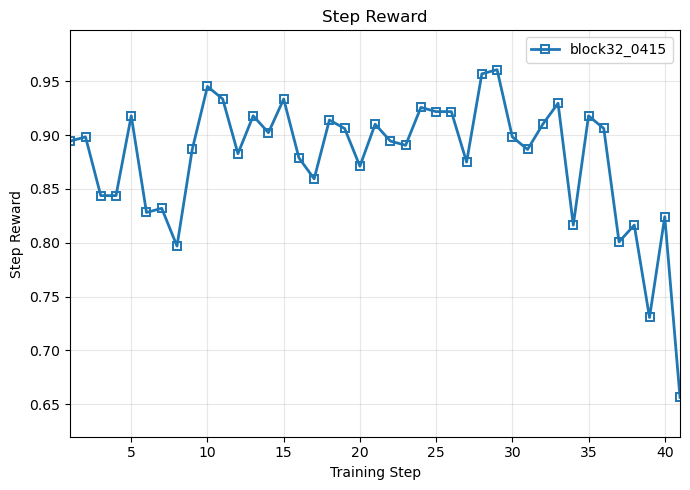

grad_norm: 41 raw points, 41 valid points in logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log
Saved to plots/grad_norm.png


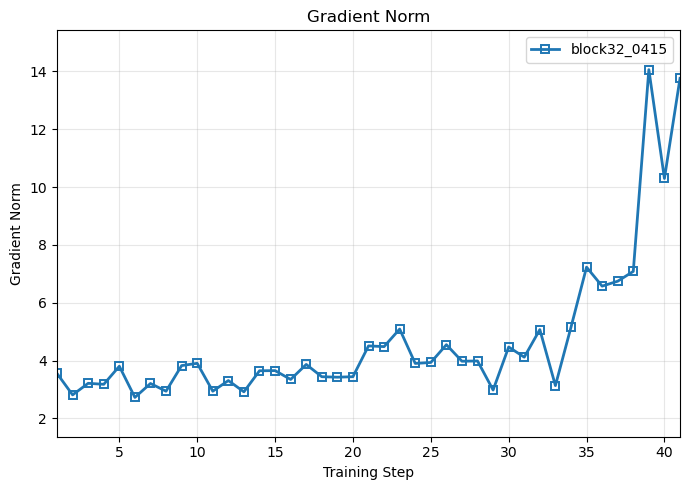

In [ ]:
TRUNCATE_TO_SHORTEST = False

curve_log_files = [
    # low diversiy
    "logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log",
    # "logs/checkpoints_gsm8k_num_generation8_test_block1_temperature0.6_lr5e-6_0424.log",
    # high diversity
    # "logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log",
    # "logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.4_lr5e-6_0501.log"
    
]

plot_all_metrics_across_files(
    log_files=curve_log_files,
    save_dir="plots/",
    smooth_window=1,
    smooth_stride=1,
    markevery=1,
    use_best_is_correct=True,
    truncate_to_shortest=TRUNCATE_TO_SHORTEST,
)

In [24]:
def parse_list_field(s):
    """
    Parse list-like fields from logs:
        ['2', '2', '3']
    """
    if s is None:
        return []

    try:
        value = ast.literal_eval(s)
        if isinstance(value, list):
            return [str(v).strip() for v in value]
        return []
    except Exception:
        return [
            a.strip().strip("'\"")
            for a in str(s).strip("[]").split(",")
            if a.strip()
        ]
    
def parse_diversity_line(line):
    try:
        content = line.strip().split("diversity|", 1)[1]

        # 用正则逐字段匹配，避免列表值里的 ": " 干扰 split
        # 匹配 key: value，value 可以是 [...] 或普通字符串（到下一个 | 为止）
        pattern = re.compile(r'(\w+)\s*:\s*(\[.*?\]|[^|]*)')
        data = {m.group(1).strip(): m.group(2).strip()
                for m in pattern.finditer(content)}

        extracted_answers  = parse_list_field(data.get("extracted_answers",  "[]"))
        normalized_answers = parse_list_field(data.get("normalized_answers", "[]"))

        return {
            "distinct_answer_num":   safe_int(data.get("distinct_answer_num", 0)),
            "all_answer_num":        safe_int(data.get("all_answer_num", len(normalized_answers) or len(extracted_answers))),
            "distinct_answer_ratio": safe_float(data.get("distinct_answer_ratio", 0)),
            "best_answer_ratio":     safe_float(data.get("best_answer_ratio", 0)),
            "correct_answer_number": safe_int(data.get("correct_answer_number", 0)),
            "best_is_correct":       safe_float(data.get("best_is_correct", np.nan)),
            "majority_answer":       data.get("majority_answer", "").strip(),
            "ground_truth":          data.get("ground_truth_answer", "").strip(),
            "extracted_answers":     extracted_answers,
            "normalized_answers":    normalized_answers,
        }

    except Exception:
        return None

def classify_sample(data):
    distinct_answer_num = data["distinct_answer_num"]
    answers = (
        data["normalized_answers"]
        if data["normalized_answers"]
        else data["extracted_answers"]
    )
    if distinct_answer_num <= 0 and answers:
        distinct_answer_num = len(set(answers))

    if distinct_answer_num <= 1:
        return "no_diversity"

    majority = data["majority_answer"]
    truth    = data["ground_truth"]

    if majority != "" and truth != "" and majority == truth:
        return "correct_label"
    return "wrong_label"


def _classify_reward(data):
    answers = (
        data["normalized_answers"]
        if data["normalized_answers"]
        else data["extracted_answers"]
    )
    distinct = data["distinct_answer_num"]
    if distinct <= 0 and answers:
        distinct = len(set(answers))

    if distinct <= 1:
        return "unusable_reward"

    majority = data["majority_answer"]
    truth    = data["ground_truth"]
    if majority != "" and truth != "" and majority == truth:
        return "correct_reward"
    return "wrong_reward"


def parse_aligned_batches(log_file):
    num      = r"[-+]?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?"
    step_pat = re.compile(
        rf"\[Step\s+(\d+)/\d+\]\s+reward=({num}),\s+grad=({num})"
    )

    batches        = []
    pending_sample = []
    pending_reward = []
    last_step_info = None

    def _flush(step_info, s_list, r_list):
        n = len(s_list)
        base = dict(step=step_info[0], reward=step_info[1], grad=step_info[2], count=n)
        if n == 0:
            base.update(dict(
                no_diversity=np.nan, correct_label=np.nan, wrong_label=np.nan,
                unusable_reward=np.nan, correct_reward=np.nan, wrong_reward=np.nan,
            ))
        else:
            base.update(dict(
                no_diversity    = s_list.count("no_diversity")    / n,
                correct_label   = s_list.count("correct_label")   / n,
                wrong_label     = s_list.count("wrong_label")     / n,
                unusable_reward = r_list.count("unusable_reward") / n,
                correct_reward  = r_list.count("correct_reward")  / n,
                wrong_reward    = r_list.count("wrong_reward")    / n,
            ))
        return base

    with open(log_file, "r", encoding="utf-8") as f:
        for line in f:
            m = step_pat.search(line)
            if m:
                step_num = int(m.group(1))
                reward   = float(m.group(2))
                grad     = float(m.group(3))
                if last_step_info is not None:
                    batches.append(_flush(last_step_info, pending_sample, pending_reward))
                    pending_sample = []
                    pending_reward = []
                last_step_info = (step_num, reward, grad)
                continue

            if "diversity|" in line:
                data = parse_diversity_line(line)
                if data is None:
                    continue
                pending_sample.append(classify_sample(data))
                pending_reward.append(_classify_reward(data))

    if last_step_info is not None and pending_sample:
        batches.append(_flush(last_step_info, pending_sample, pending_reward))

    return batches


def plot_collapse_analysis(log_files, save_dir=None, figsize_per=(10, 4)):
    SAMPLE_KEYS   = ["no_diversity",    "wrong_label",    "correct_label"]
    SAMPLE_COLORS = ["#888780",         "#D85A30",        "#1D9E75"]
    SAMPLE_LABELS = [
        "No diversity (all same)",
        "Wrong label (diverse, wrong majority)",
        "Correct label (diverse, right majority)",
    ]
    REWARD_KEYS   = ["unusable_reward", "wrong_reward",   "correct_reward"]
    REWARD_COLORS = ["#888780",         "#D85A30",        "#1D9E75"]
    REWARD_LABELS = [
        "Unusable reward (no diversity)",
        "Wrong reward (diverse, wrong majority)",
        "Correct reward (diverse, right majority)",
    ]

    n           = len(log_files)
    W           = figsize_per[0] * n
    all_batches = [parse_aligned_batches(lf) for lf in log_files]

    # ── Figure 1: reward & grad ──────────────────────────────────────────
    fig1, axes1 = plt.subplots(1, n, figsize=(W, figsize_per[1]), squeeze=False)
    for col, (log_file, batches) in enumerate(zip(log_files, all_batches)):
        ax = axes1[0][col]
        if not batches:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(pretty_label(log_file))
            continue

        steps   = [b["step"]   for b in batches]
        rewards = [b["reward"] for b in batches]
        grads   = [b["grad"]   for b in batches]

        ax2 = ax.twinx()
        l1, = ax.plot(steps, rewards, color="#1D9E75", linewidth=2,
                      marker="o", markersize=4, markerfacecolor="none",
                      markeredgewidth=1.4, label="reward")
        l2, = ax2.plot(steps, grads, color="#D85A30", linewidth=2,
                       marker="s", markersize=4, markerfacecolor="none",
                       markeredgewidth=1.4, label="grad norm", linestyle="--")
        ax.set_xlabel("Training step", fontsize=11)
        ax.set_ylabel("Reward", fontsize=11, color="#1D9E75")
        ax2.set_ylabel("Grad norm", fontsize=11, color="#D85A30")
        ax.tick_params(axis="y", labelcolor="#1D9E75")
        ax2.tick_params(axis="y", labelcolor="#D85A30")
        ax.set_title(pretty_label(log_file), fontsize=12)
        ax.grid(alpha=0.3)
        ax.legend(handles=[l1, l2], loc="upper left", fontsize=9, framealpha=0.85)

    fig1.suptitle("Reward & Gradient norm over training", fontsize=13, y=1.02)
    fig1.tight_layout()
    if save_dir is not None:
        Path(save_dir).mkdir(parents=True, exist_ok=True)
        p = Path(save_dir) / "reward_grad.png"
        fig1.savefig(p, dpi=300, bbox_inches="tight")
        print(f"Saved → {p}")
    plt.show(); plt.close(fig1)

    # ── shared stacked-bar helper ────────────────────────────────────────
    def _stacked(fig, axes, suptitle, keys, colors, labels):
        for col, (log_file, batches) in enumerate(zip(log_files, all_batches)):
            ax = axes[0][col]
            valid = [b for b in batches if b["count"] > 0]
            if not valid:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(pretty_label(log_file))
                continue

            steps   = [b["step"]  for b in valid]
            counts  = [b["count"] for b in valid]
            bottoms = np.zeros(len(steps))

            for key, color, label in zip(keys, colors, labels):
                prop = np.array([b[key] for b in valid], dtype=float)
                prop = np.where(np.isnan(prop), 0, prop)
                ax.bar(steps, prop, label=label, color=color,
                       bottom=bottoms, width=0.8, edgecolor="none")
                bottoms += prop

            ax.set_xlabel("Training step", fontsize=11)
            ax.set_ylabel("Proportion", fontsize=11)
            ax.set_ylim(0, 1.0)
            ax.set_xlim(min(steps) - 0.5, max(steps) + 0.5)
            ax.set_title(pretty_label(log_file), fontsize=12)
            ax.grid(axis="y", alpha=0.3)
            ax.legend(loc="upper left", fontsize=9, framealpha=0.85)
            ax.set_xticks(steps)
            ax.set_xticklabels(
                [f"{s}\n(n={c})" for s, c in zip(steps, counts)],
                fontsize=7, rotation=45, ha="right",
            )

        fig.suptitle(suptitle, fontsize=13, y=1.02)
        fig.tight_layout()
        if save_dir is not None:
            fname = suptitle.split()[0].lower() + ".png"
            p = Path(save_dir) / fname
            fig.savefig(p, dpi=300, bbox_inches="tight")
            print(f"Saved → {p}")
        plt.show(); plt.close(fig)

    # ── Figure 2: sample label composition ──────────────────────────────
    fig2, axes2 = plt.subplots(1, n, figsize=(W, figsize_per[1]), squeeze=False)
    _stacked(fig2, axes2, "Sample label composition per step",
             SAMPLE_KEYS, SAMPLE_COLORS, SAMPLE_LABELS)

    # ── Figure 3: reward composition ────────────────────────────────────
    fig3, axes3 = plt.subplots(1, n, figsize=(W, figsize_per[1]), squeeze=False)
    _stacked(fig3, axes3, "Reward composition per step",
             REWARD_KEYS, REWARD_COLORS, REWARD_LABELS)

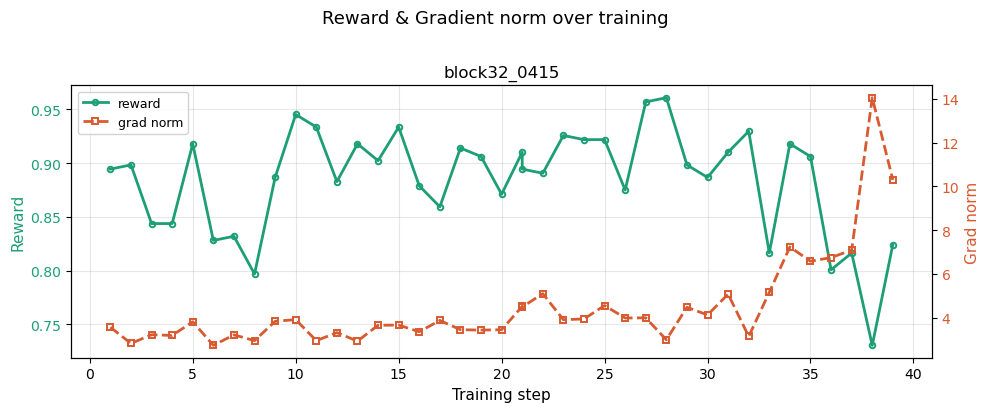

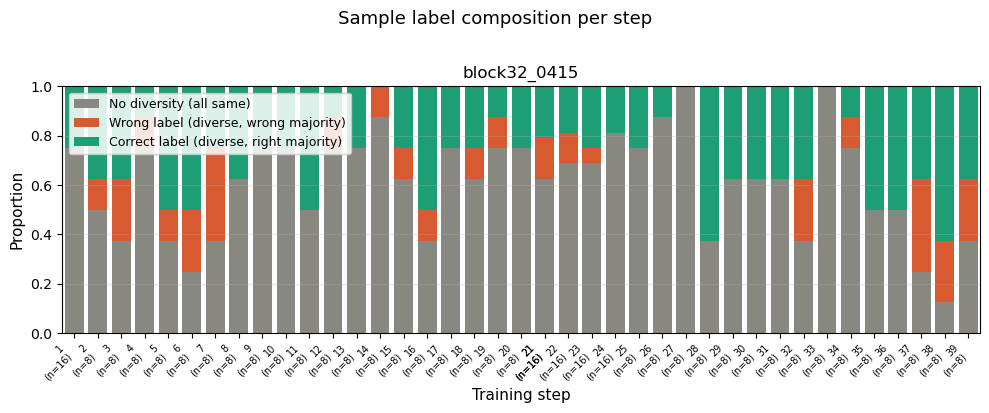

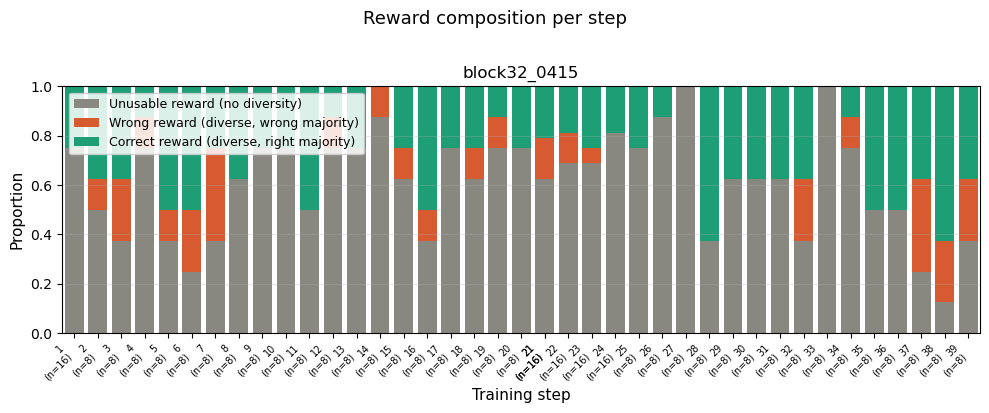

In [25]:
curve_log_files = [
    # low diversiy
    "logs/checkpoints_gsm8k_num_generation8_test_block32_0415.log",
    # "logs/checkpoints_gsm8k_num_generation8_test_block1_temperature0.6_lr5e-6_0424.log",
    # high diversity
    # "logs/checkpoints_gsm8k_num_generation8_test_block1_0315.log",
    # "logs/checkpoints_gsm8k_num_generation8_test_block32_temperature1.4_lr5e-6_0501.log"
    
]

plot_collapse_analysis(
    log_files=curve_log_files,
    save_dir=None,
)

In [28]:
def print_step_diversity_logs(log_file, target_step):
    """
    Print all diversity| lines that belong to target_step,
    i.e. between [Step target_step/...] and the reward= line of that step.
    """
    num      = r"[-+]?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?"
    step_pat = re.compile(r'\[Step\s+(\d+)/\d+\]')
    reward_pat = re.compile(rf'\[Step\s+(\d+)/\d+\]\s+reward=({num}),\s+grad=({num})')

    in_target    = False
    pending_lines = []

    with open(log_file, "r", encoding="utf-8") as f:
        for line in f:
            # reward= 行：flush
            m_reward = reward_pat.search(line)
            if m_reward:
                if int(m_reward.group(1)) == target_step:
                    print(f"=== Diversity logs for Step {target_step} (n={len(pending_lines)}) ===")
                    for l in pending_lines:
                        print(l, end="")
                    return
                continue

            # 普通 step 行：判断是否进入 target
            m_step = step_pat.search(line)
            if m_step:
                in_target = (int(m_step.group(1)) == target_step)
                continue

            if in_target and "diversity|" in line:
                pending_lines.append(line)

    print(f"Step {target_step} not found or has no diversity logs in {log_file}")


print_step_diversity_logs(curve_log_files[0], target_step=34)

=== Diversity logs for Step 34 (n=8) ===
diversity| distinct_answer_num: 1 | all_answer_num: 8 | distinct_answer_ratio: 0.12 | best_answer_ratio: 1.00 | correct_answer_number: 8 | best_is_correct: 1 | extracted_answers: ['8', '8', '8', '8', '8', '8', '8', '8'] | normalized_answers: ['8', '8', '8', '8', '8', '8', '8', '8'] | majority_answer: 8 | ground_truth_answer: 8
diversity| distinct_answer_num: 1 | all_answer_num: 8 | distinct_answer_ratio: 0.12 | best_answer_ratio: 1.00 | correct_answer_number: 8 | best_is_correct: 1 | extracted_answers: ['3', '3', '3', '3', '3', '3', '3', '3'] | normalized_answers: ['3', '3', '3', '3', '3', '3', '3', '3'] | majority_answer: 3 | ground_truth_answer: 3
diversity| distinct_answer_num: 1 | all_answer_num: 8 | distinct_answer_ratio: 0.12 | best_answer_ratio: 1.00 | correct_answer_number: 8 | best_is_correct: 1 | extracted_answers: ['800', '800', '800', '800', '800', '800', '800', '800'] | normalized_answers: ['800', '800', '800', '800', '800', '800', 